In [13]:
import numpy as np
from os import listdir

from ExistingAlgorithms.Plot import plot_traces
from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.decibels import file_name_table_npy, decibel_table_npy
from AutoencoderAPI.utils.correlation import second_order
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture
from AutoencoderAPI.utils.confidence import confidence
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sklearn.manifold import TSNE
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from sklearn.decomposition import PCA

In [14]:
signal_size = 30_000
path_train = 'Datasets/SNSPD/Paderborn/data/'
path_model = 'run-2024-01-20-17-58/fold 0'
mean_model, std_model = load_mean_std(path_model)

#X_train = np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::2, 3250:4500] for fileName in listdir(path_train)[::2]])
#X_train = (X_train - mean_model)/std_model
#X_zeros = X_train[np.min(X_train, axis=1) >= 1.6]
#X_train = X_train[np.min(X_train, axis=1) < -0.5]
#X_train = X_train[np.max(X_train, axis=1) > 1]

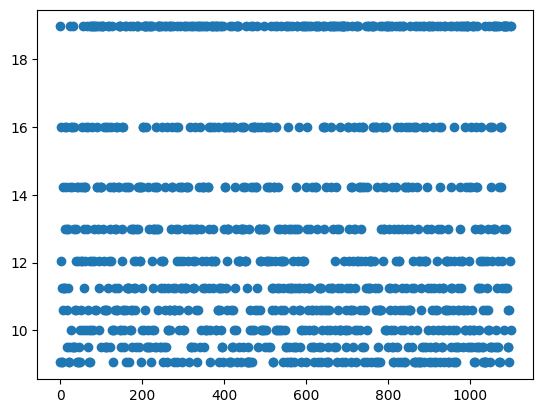

In [3]:
x = np.load('Datasets/SNSPD/Paderborn/db_shuffled.npy')
plt.scatter(range(len(x)), x)
plt.show()

# Poissonian statistics for t-SNE

In [4]:
X, decibel_samples = decibel_table_npy('Datasets/SNSPD/Paderborn/data test', #, decibel_zeros
                                'Datasets/SNSPD/Paderborn/db_shuffled.npy', 
                                30_000,
                                mean_model, 
                                std_model)

In [5]:
#method = TSNE(n_components=1, perplexity=1000)
#X_l = method.fit_transform(X)

In [7]:
#np.save("MetricLog/Metric_SNSPD/temp_tsne_SNSPD1000",X_l)
X_l = np.load("MetricLog/Metric_SNSPD/temp_tsne_SNSPD1000.npy")

X_l = (X_l - np.min(X_l)) / (np.max(X_l) - np.min(X_l))
#X_l = X_l[np.logical_not((X_l >= -0.85) & (X_l <= -0.8))]

FileNotFoundError: [Errno 2] No such file or directory: 'MetricLog/Metric_SNSPD/temp_tsne_SNSPD1000.npy'

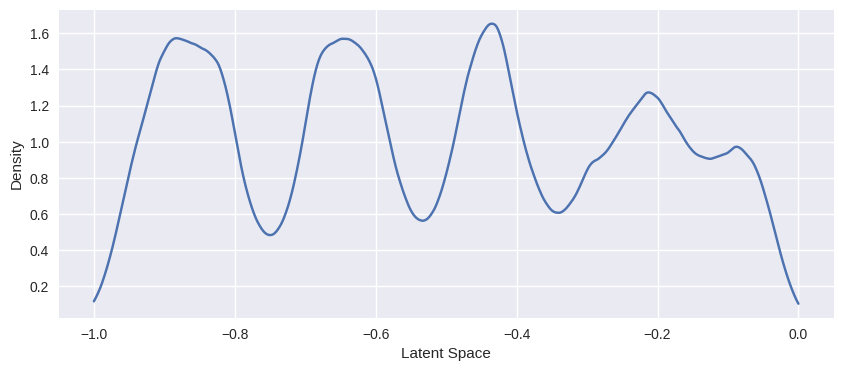

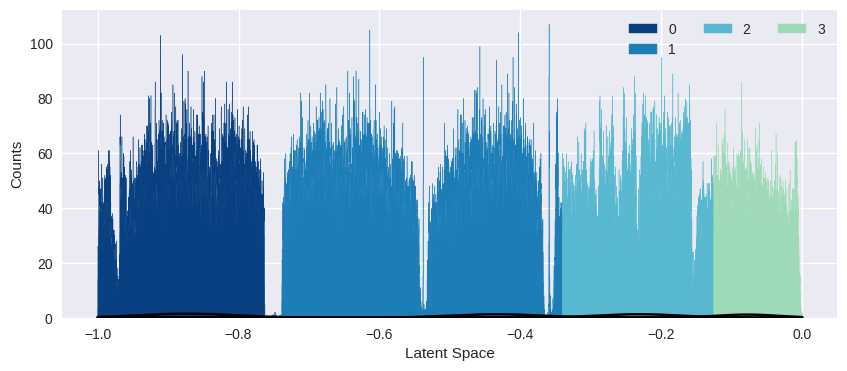

IndexError: boolean index did not match indexed array along dimension 0; dimension is 301000 but corresponding boolean dimension is 243056

<Figure size 1000x400 with 0 Axes>

In [ ]:
kd = density_gaussianMixture(X_l,
                            bw = [0.0635], #0.045
                            bins_plot = 5000,
                            density_kernel='cosine',
                            flip = True,
                            skip =10)

kd.plot_density()
kd.plot_cluster()
kd.plot_traces_average(X)
kd.plot_cross_talk()
labels = kd.labels

9.05


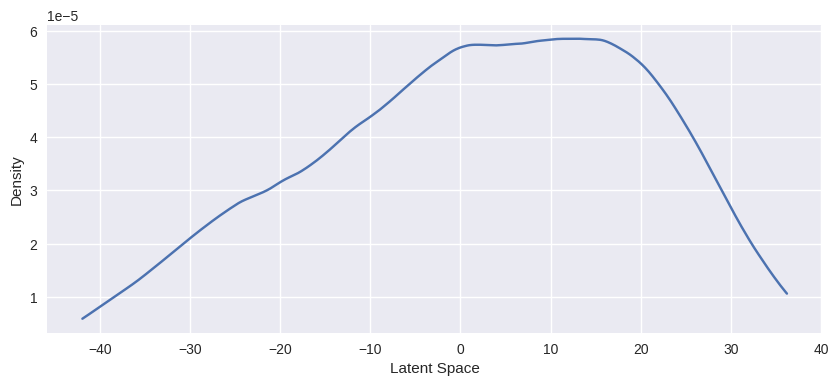

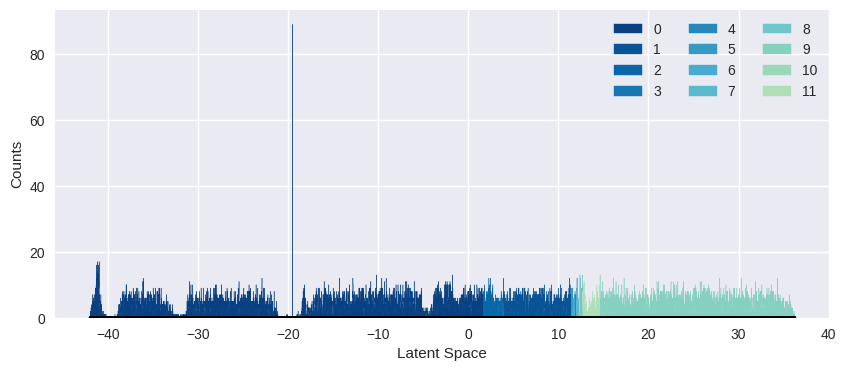

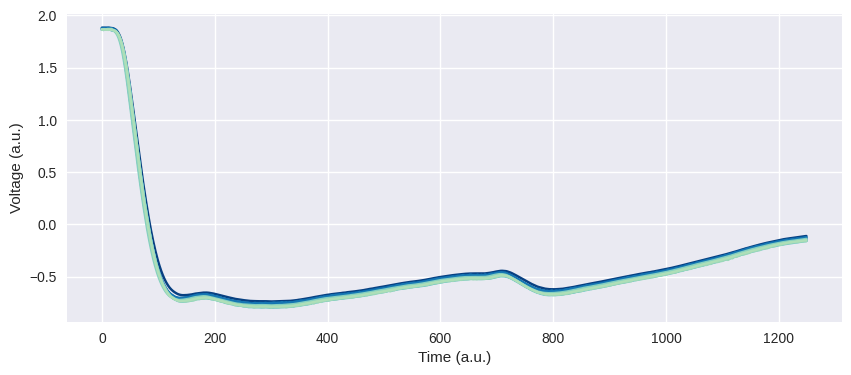

/home/nicolasdc/files/Single-Photon-Detection/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:134: RuntimeWarning: invalid value encountered in sqrt
  inter = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)
/home/nicolasdc/files/Single-Photon-Detection/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:145: RuntimeWarning: invalid value encountered in sqrt
  inter = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)


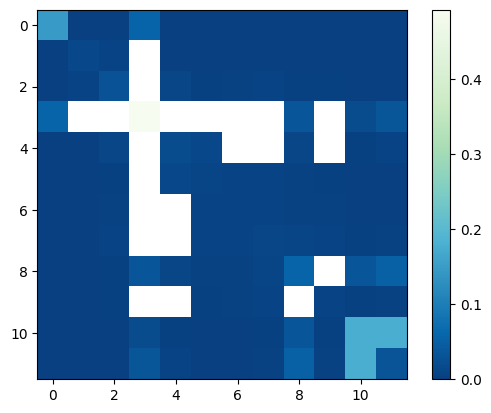

9.5


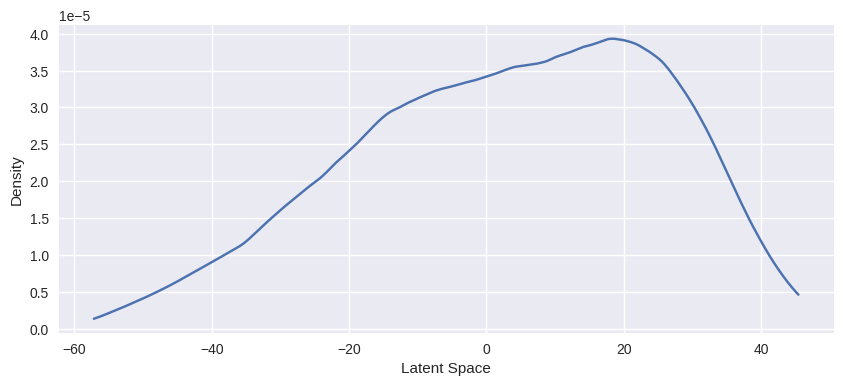

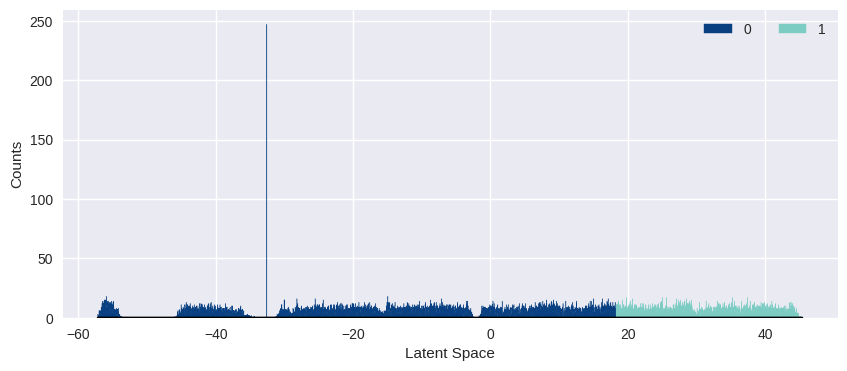

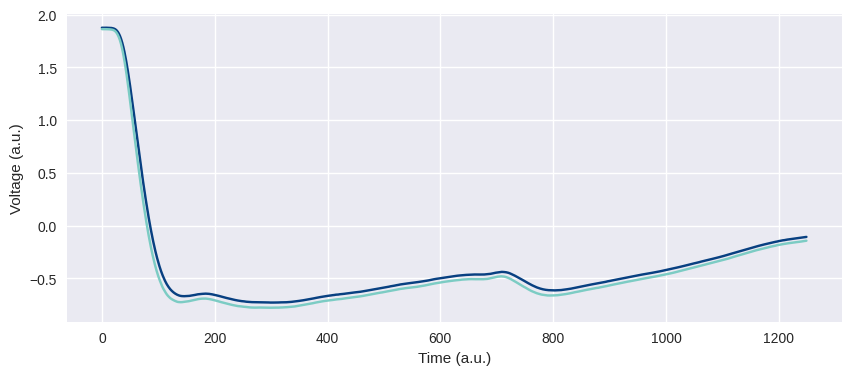

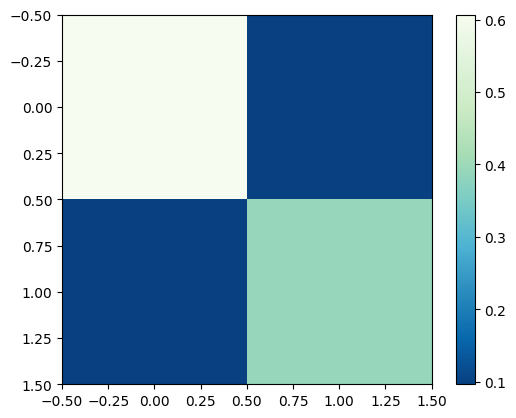

10.01


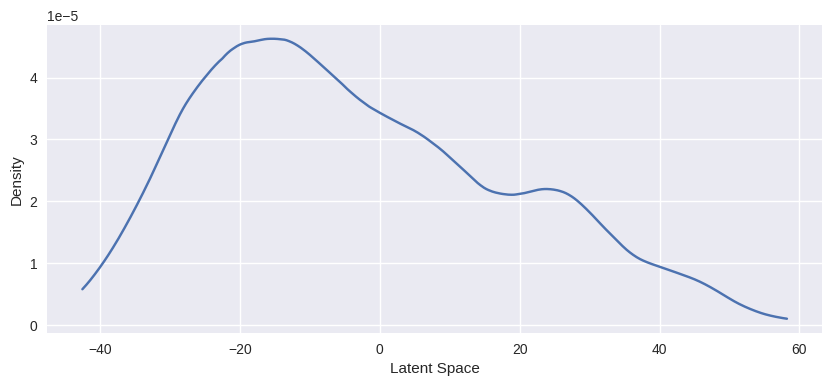

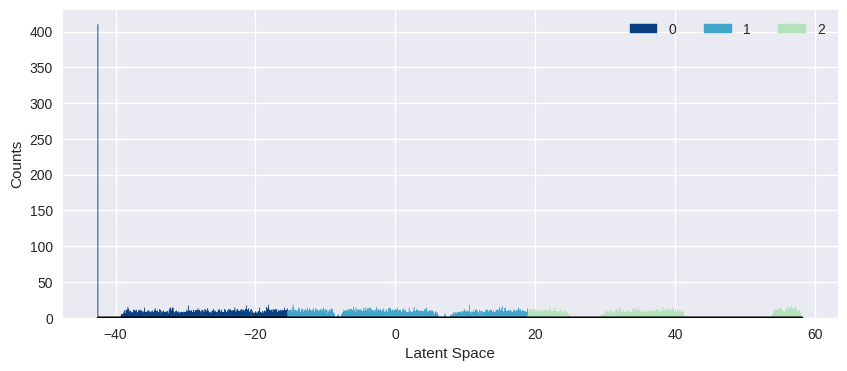

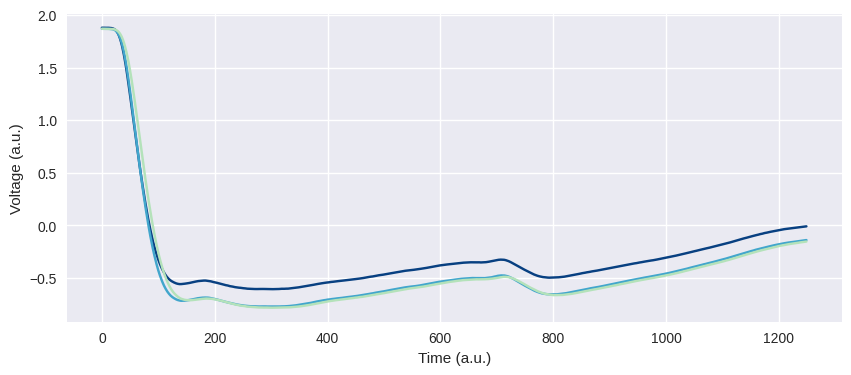

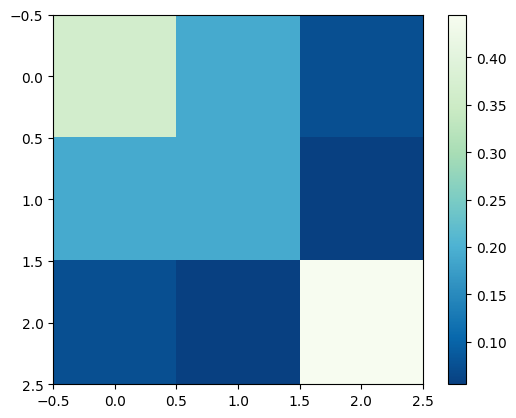

10.59


KeyboardInterrupt: 

In [ ]:
decibel = []
g2 = []
average = []
bw = []
db = np.unique(decibel_samples)#[-3:]

for index, key in enumerate(db):

    print(key)
    condition = decibel_samples == key

    labels_ = labels[condition]
    X_ = X[condition]
    #zeros = decibel_zeros[decibel_zeros == key]

    #labels_ = np.append(labels_, np.zeros(len(zeros)))

    method = TSNE(n_components=1, perplexity=1000)
    X_l = method.fit_transform(X_)

    kd = density_gaussianMixture(X_l,
                            bw = [20], #0.045
                            min_cluster_prob = 0.01,
                            bins_plot = 5000,
                            density_kernel='cosine',
                            flip = True,
                            skip =10)

    kd.plot_density()
    kd.plot_cluster()
    kd.plot_traces_average(X_)
    kd.plot_cross_talk()
    #labels = kd.labels

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

# dB evaluation

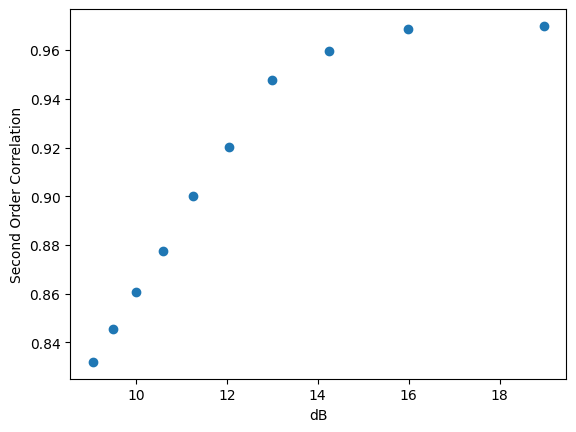

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB/10 )

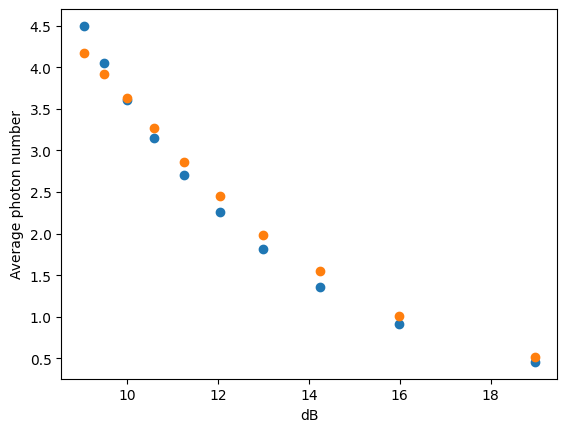

[36.12432786  0.1       ]


In [ ]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -10], [1e4, 10]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt))
plt.scatter(decibel, average,marker='o' )
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.show()
print(popt)

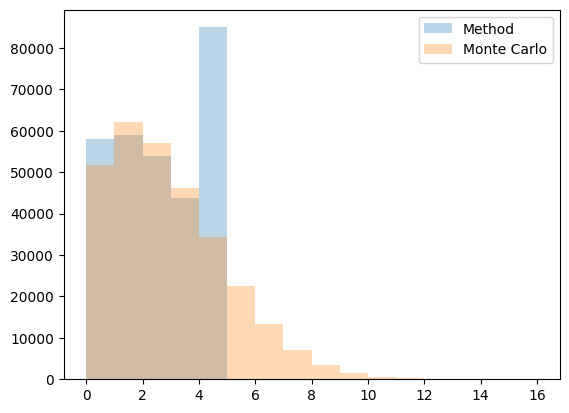

In [ ]:
import numpy.random as npr

average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 30_000) for i in average])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poissonian statistics for PCA

In [35]:
X, decibel_samples = decibel_table_npy('Datasets/SNSPD/Paderborn/data test', 
                                'Datasets/SNSPD/Paderborn/db_shuffled.npy', 
                                30_000,
                                mean_model, 
                                std_model)#, decibel_zeros

condition = np.min(X, axis=1) < -0.55
X = X[condition]
decibel_samples = decibel_samples[condition]
condition = np.max(X, axis=1) > 0
X = X[condition]
decibel_samples = decibel_samples[condition]

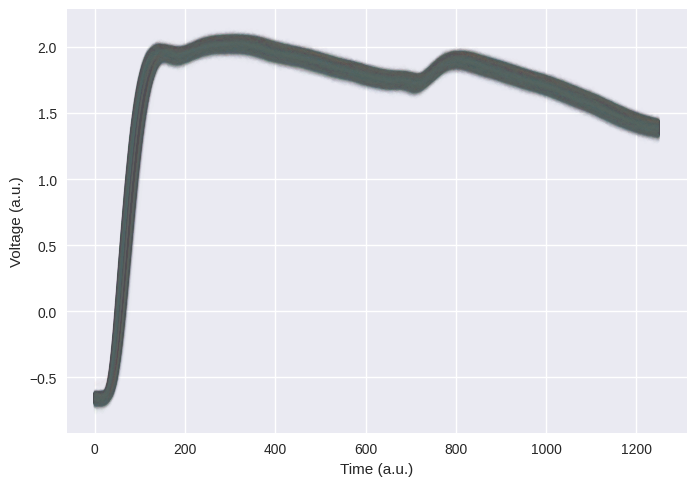

In [9]:
plot_traces(X)

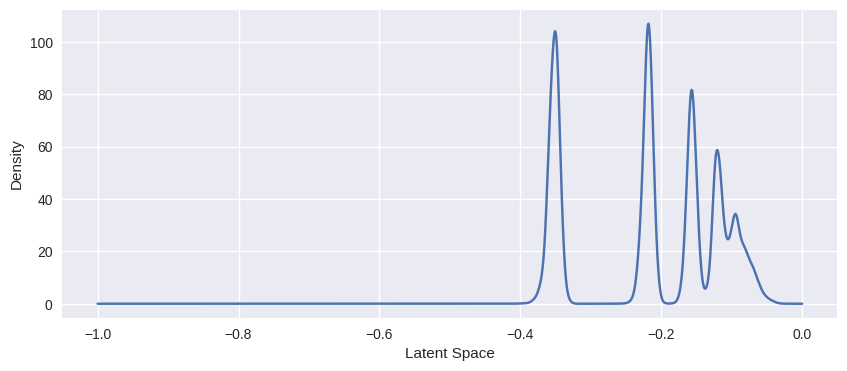

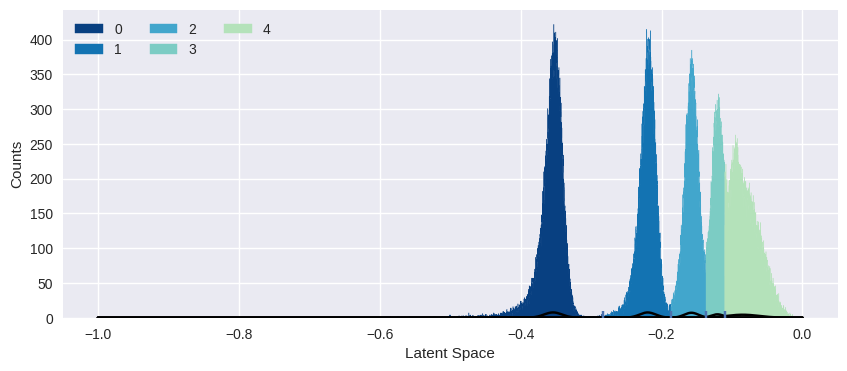

9.05


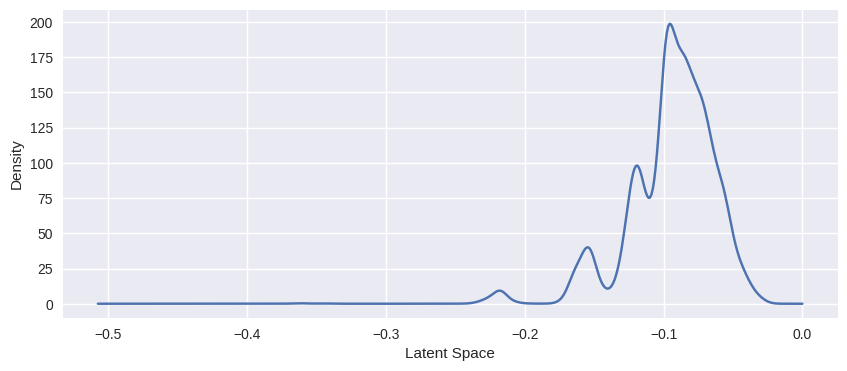

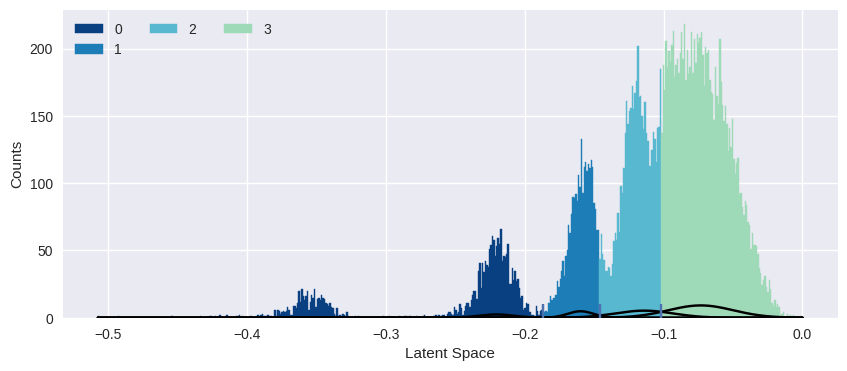

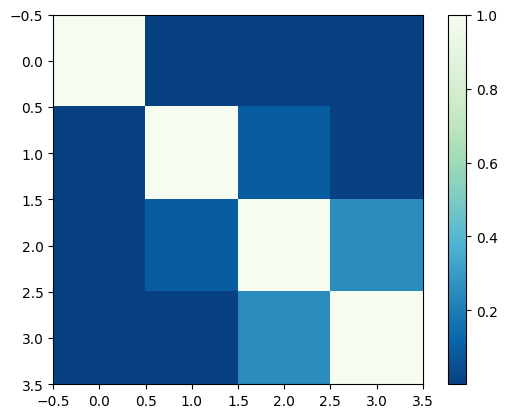

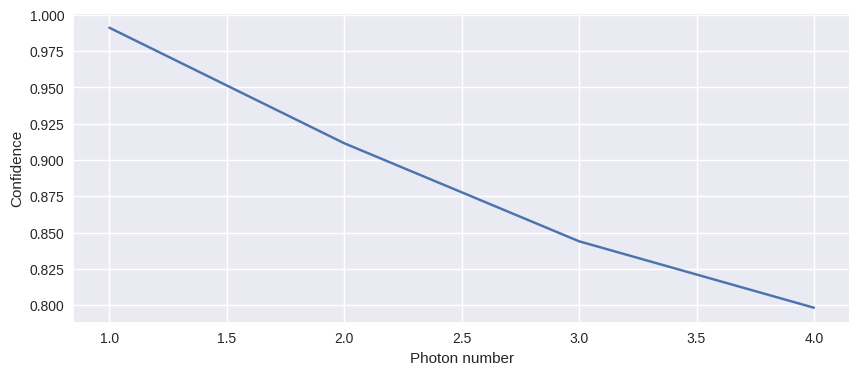

9.5


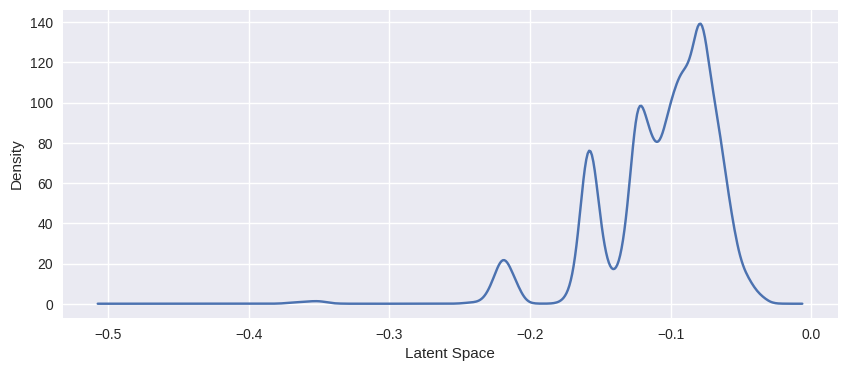

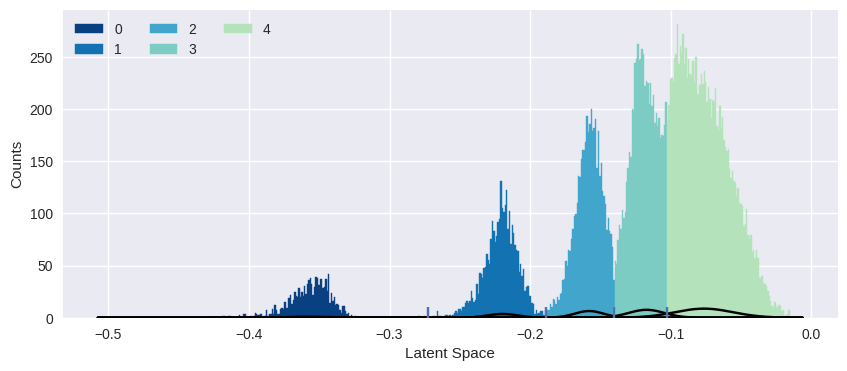

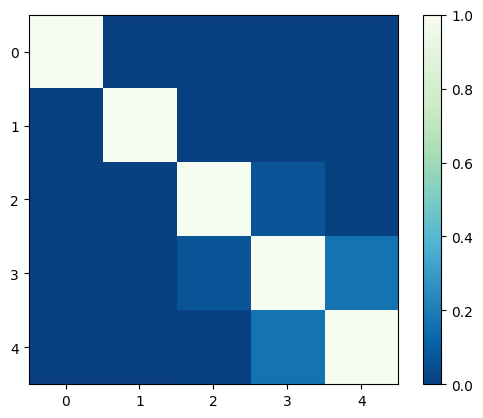

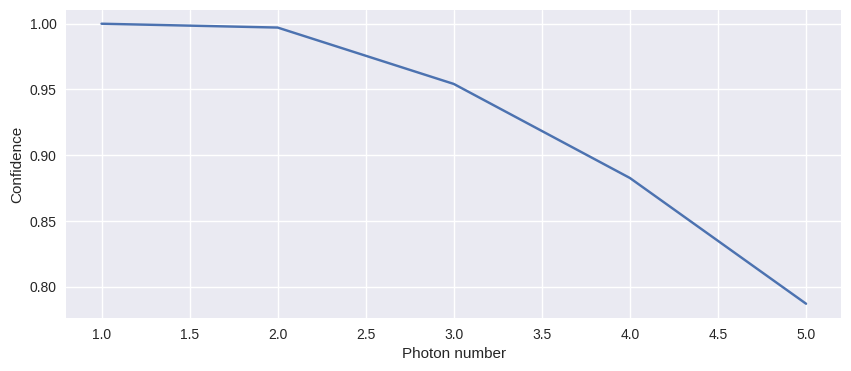

10.01


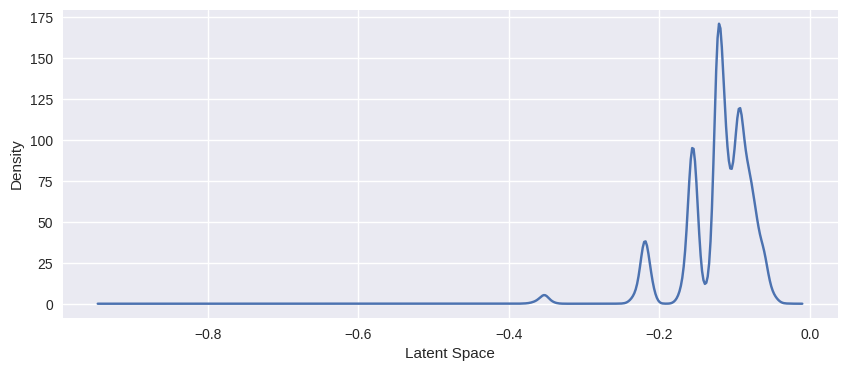

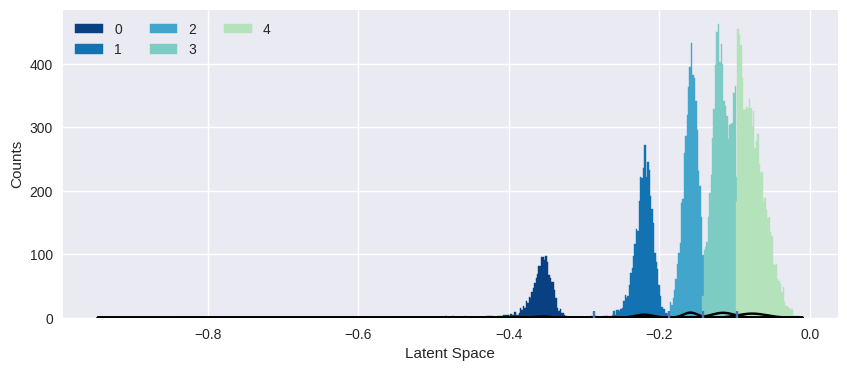

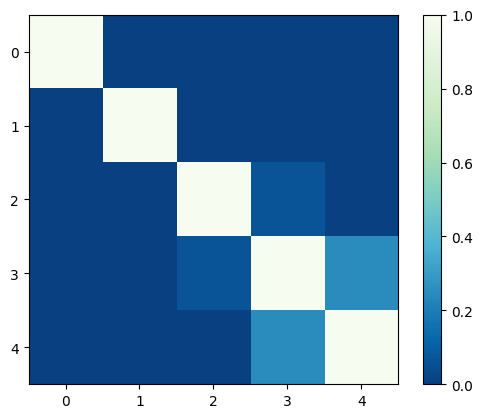

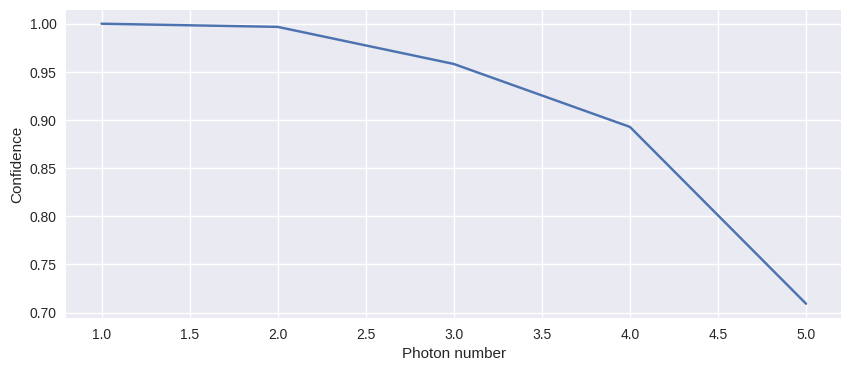

10.59


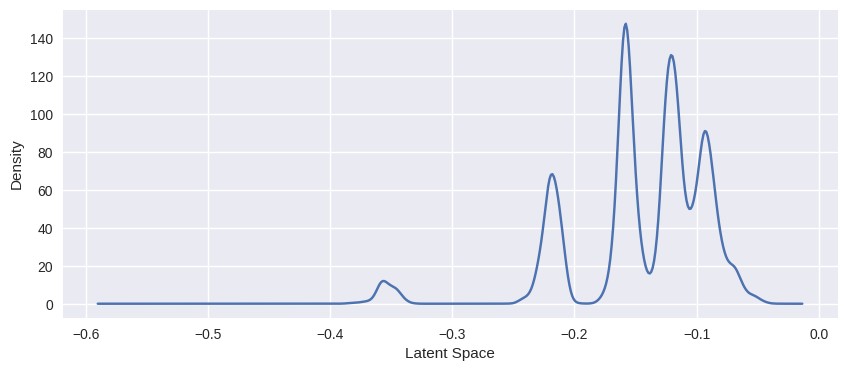

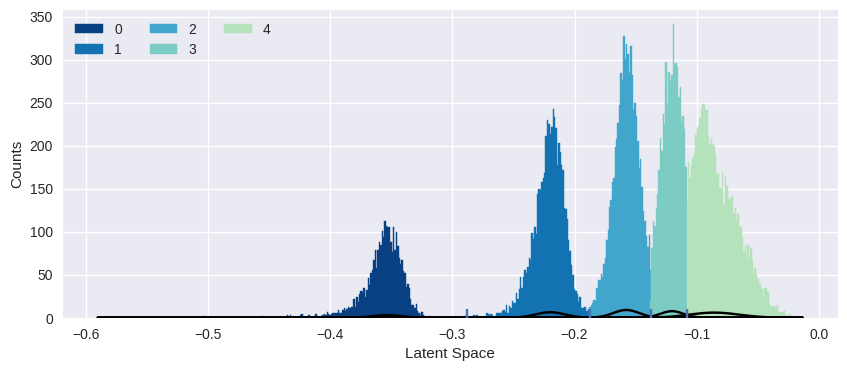

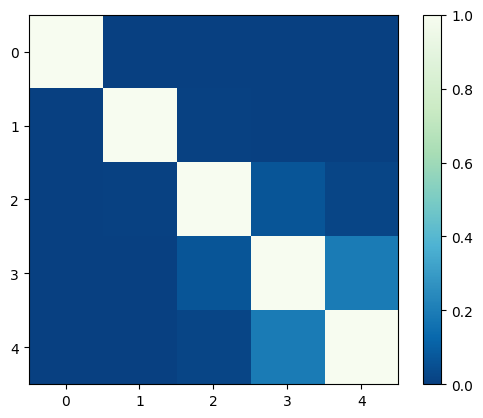

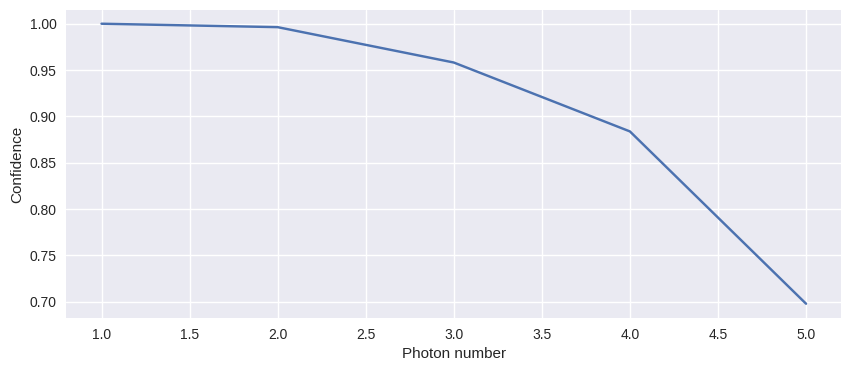

11.25


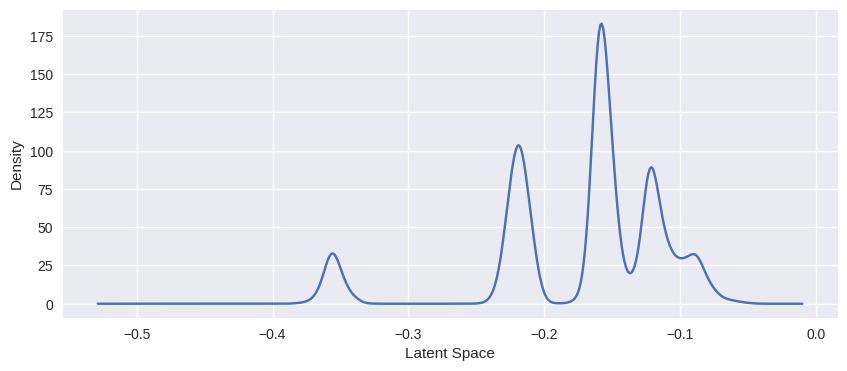

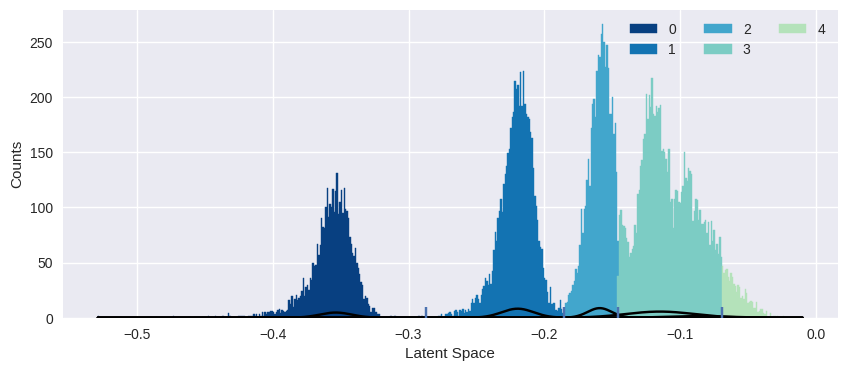

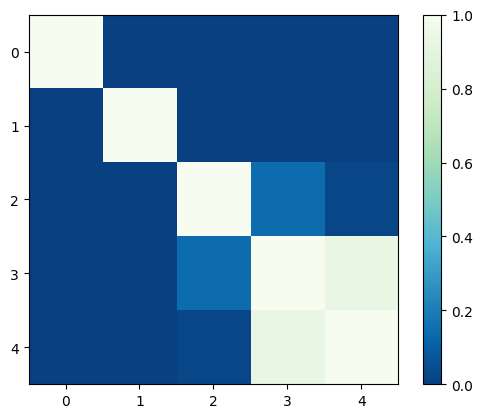

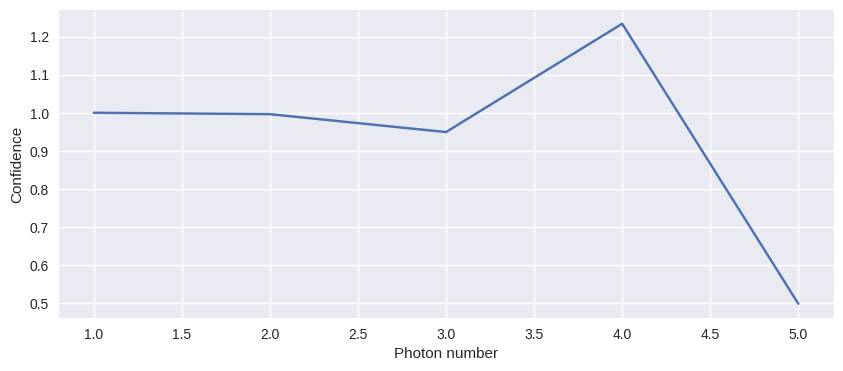

12.04


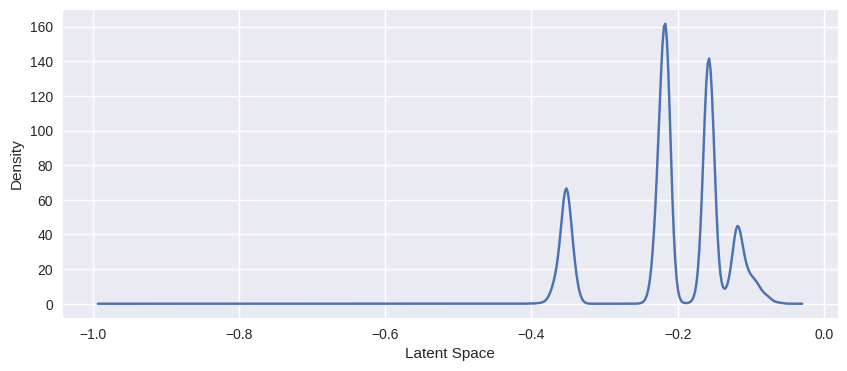

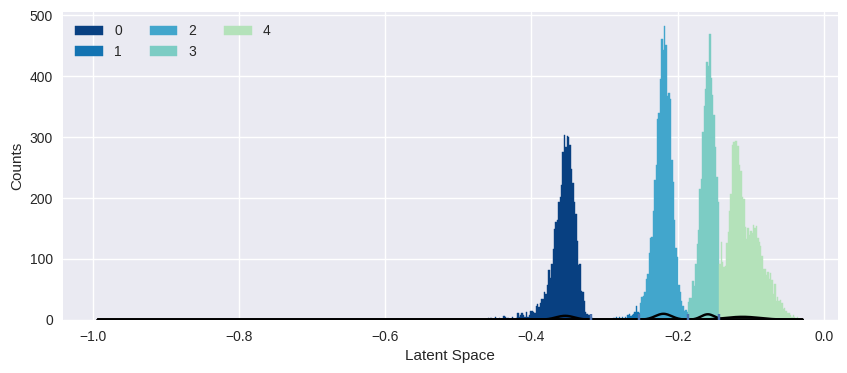

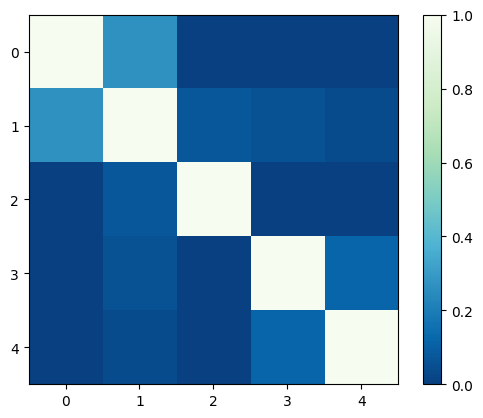

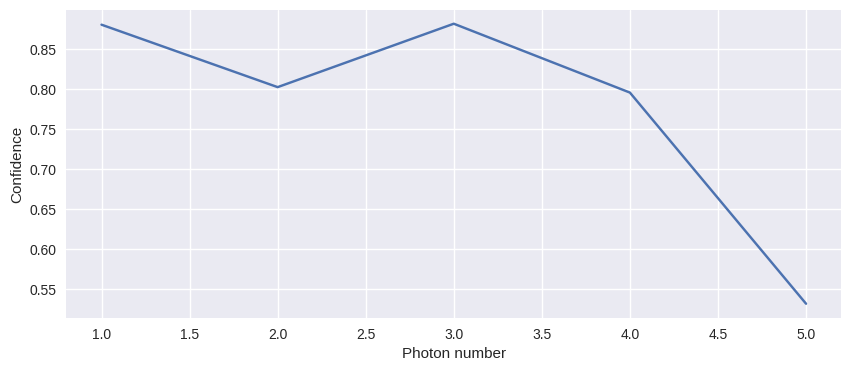

13.0


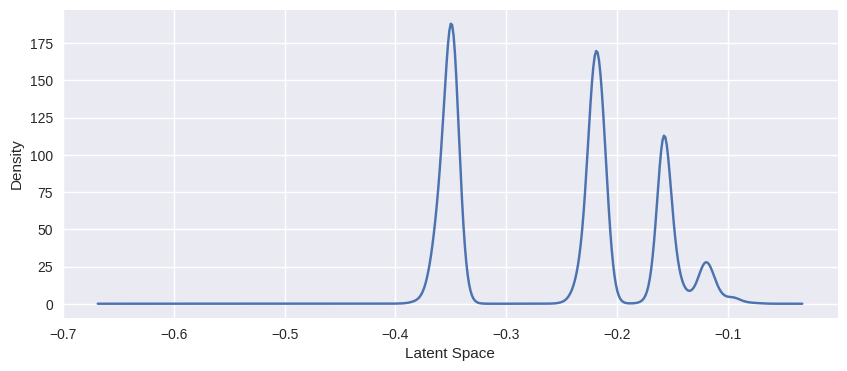

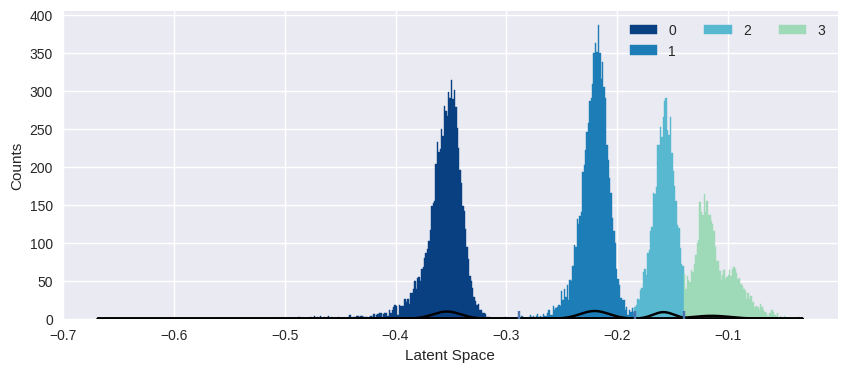

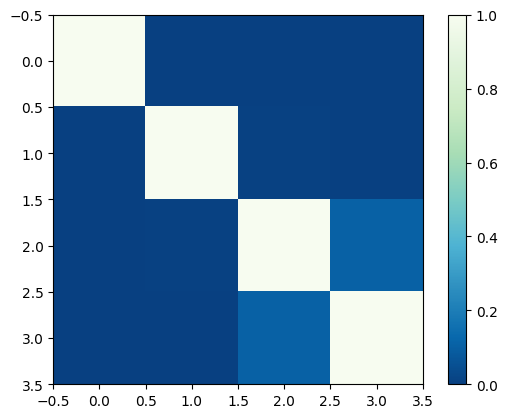

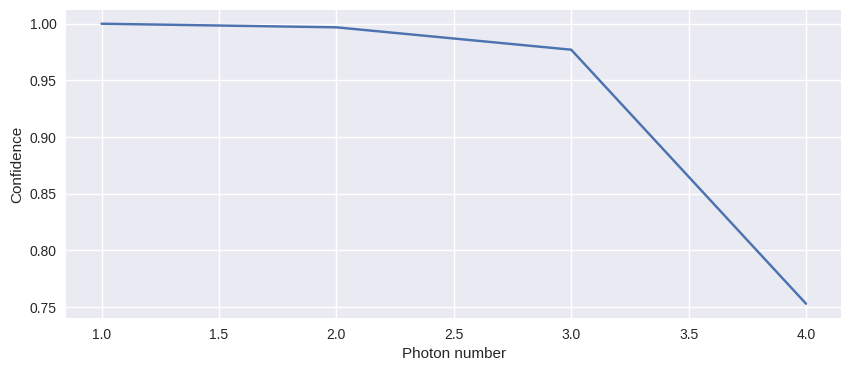

14.24


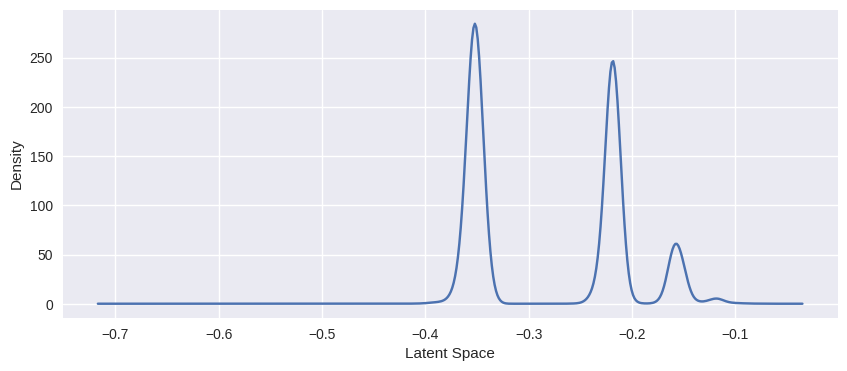

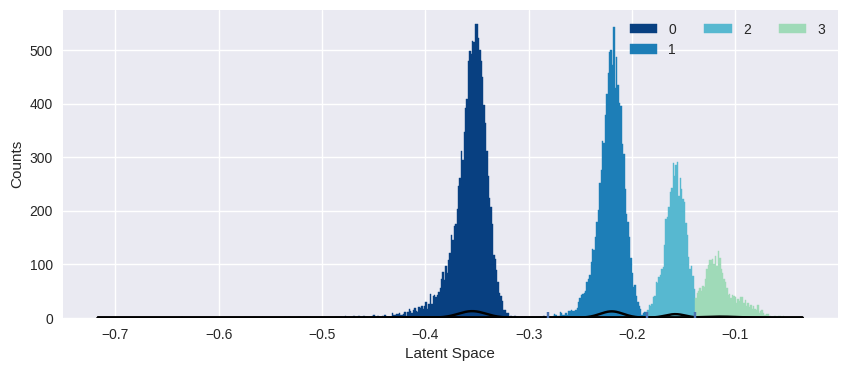

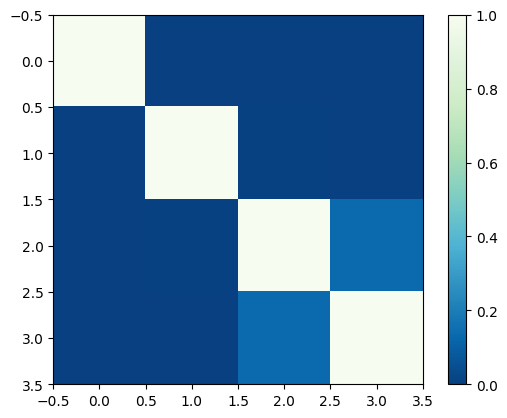

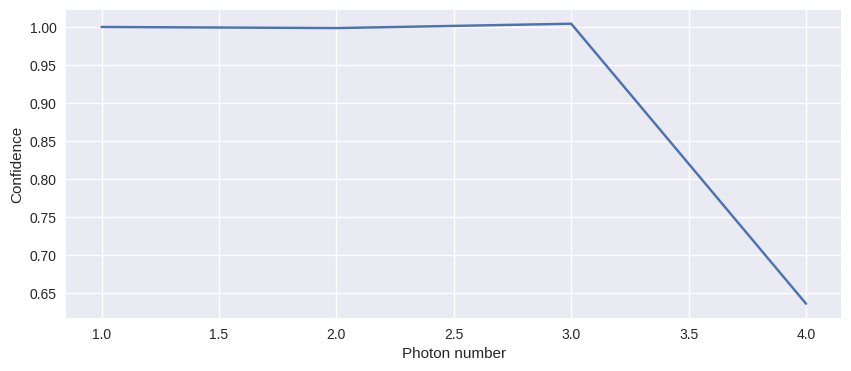

15.99


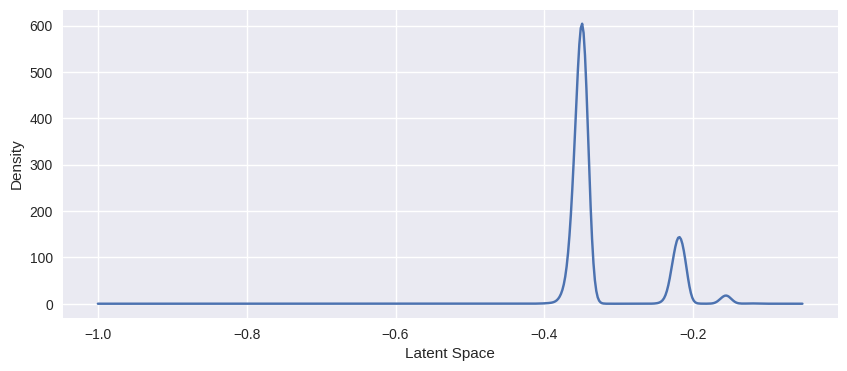

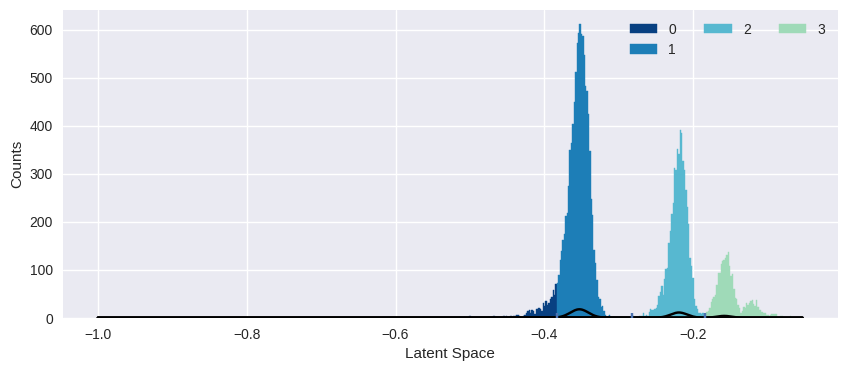

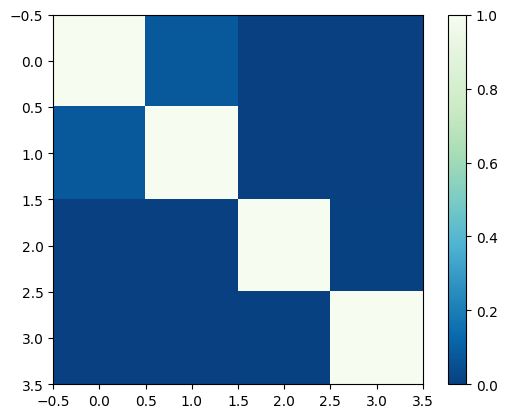

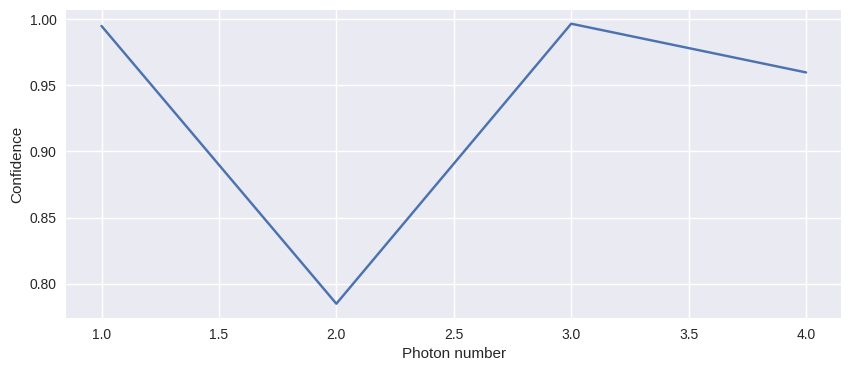

18.97


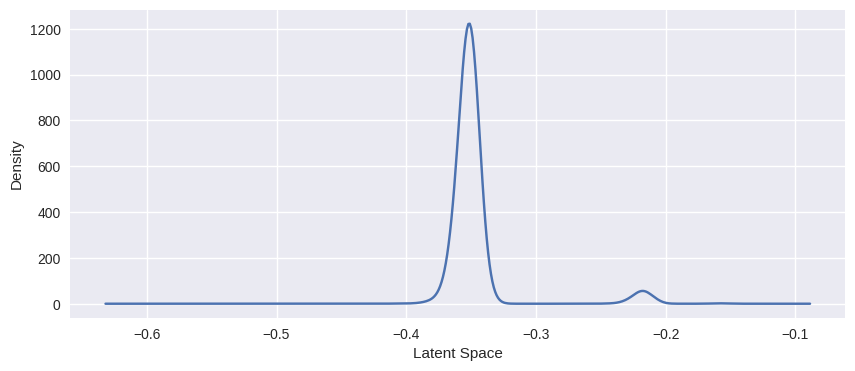

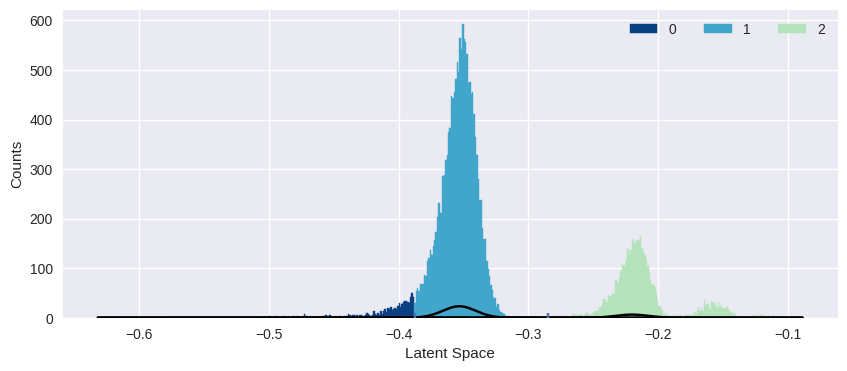

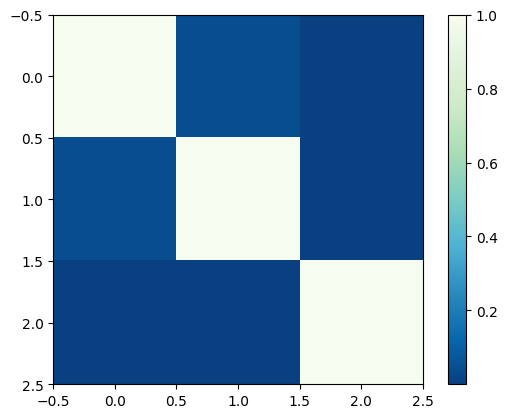

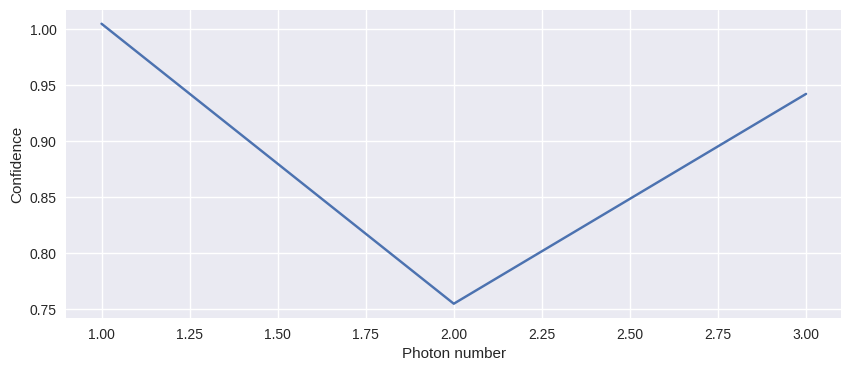

In [36]:
decibel = []
g2 = []
average = []

method = PCA(n_components=1)
X_l = method.fit_transform(X)
X_l = (X_l-np.min(X_l)) / (np.max(X_l)-np.min(X_l))

conf = confidence(X_l,
                bw = [0.0035], 
                min_cluster_prob = 0.04,
                bins_plot = 5000,
                density_kernel='gaussian',
                flip = True, 
                skip = 10)

labels = conf.labels
bw_list = [0.005, 0.005, 0.005, 0.004, 0.005, 0.006, 0.006, 0.006, 0.006, 0.006]
min_prob_list = [0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.045, 0.045, 0.045]

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key

    conf.fit(X_l[condition],
            bw = [bw_list[index]], 
            min_cluster_prob = min_prob_list[index],
            bins_plot = 500,
            density_kernel='gaussian',
            flip = True, 
            skip = 10)
    
    labels_ = labels[condition]

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

# dB evaluation

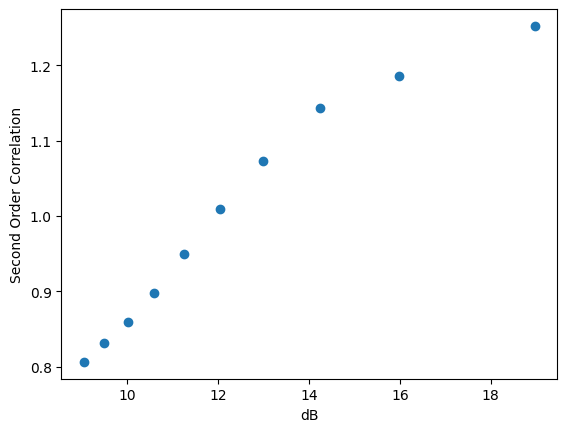

In [53]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [10]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB/10 )

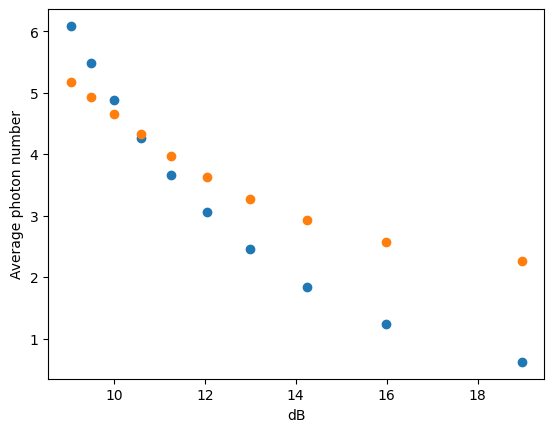

[48.89478657  0.1       ]


In [11]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -10], [1e4, 10]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt))
plt.scatter(decibel, average,marker='o' )
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.show()
print(popt)

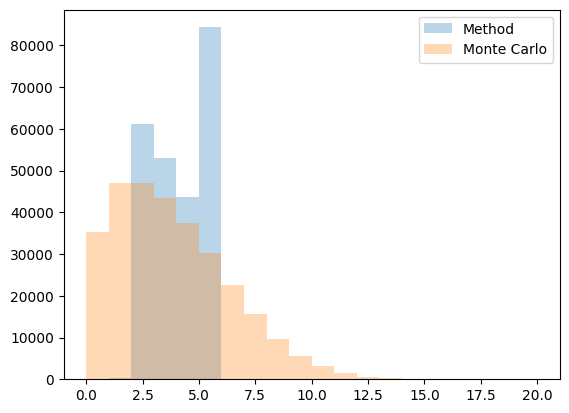

In [12]:
import numpy.random as npr

average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 30_000) for i in average])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poisson statistic of Autoencoder

In [96]:
X, decibel_samples = decibel_table_npy('Datasets/SNSPD/Paderborn/data test', #, decibel_zeros
                                'Datasets/SNSPD/Paderborn/db_shuffled.npy', 
                                30_000,
                                mean_model, 
                                std_model)

#X = (X - mean_model) / std_model
#X = X[:,::2]
#condition = np.min(X, axis=1) < -0.55
#X = X[condition]
#decibel_samples = decibel_samples[condition]

condition = np.min(X, axis=1) < -0.55
X = X[condition]
decibel_samples = decibel_samples[condition]
condition = np.max(X, axis=1) > 0
X = X[condition]
decibel_samples = decibel_samples[condition]

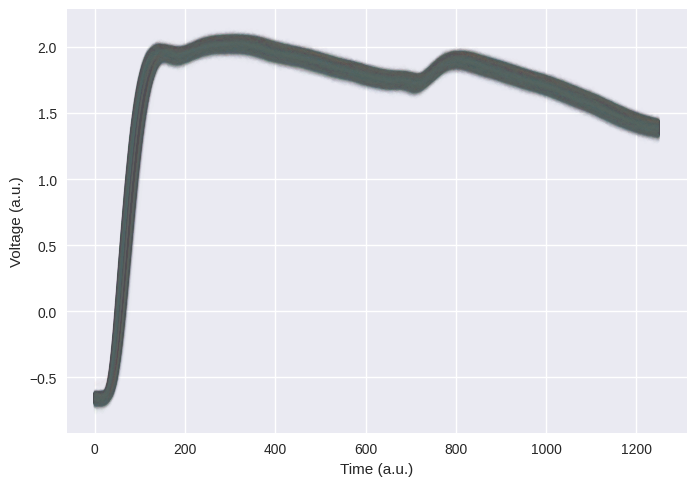

In [66]:
plot_traces(X)

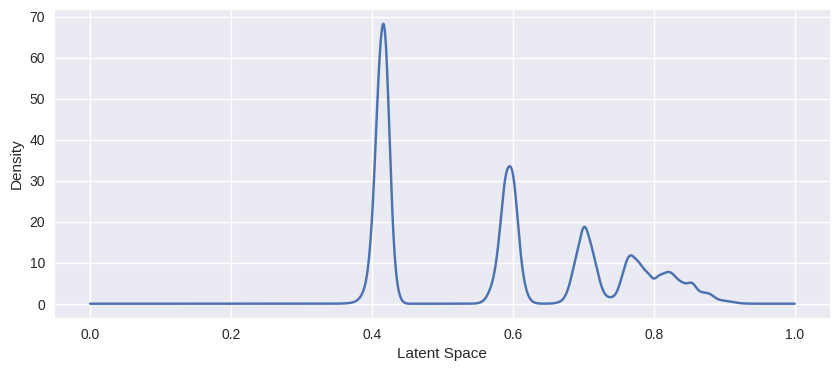

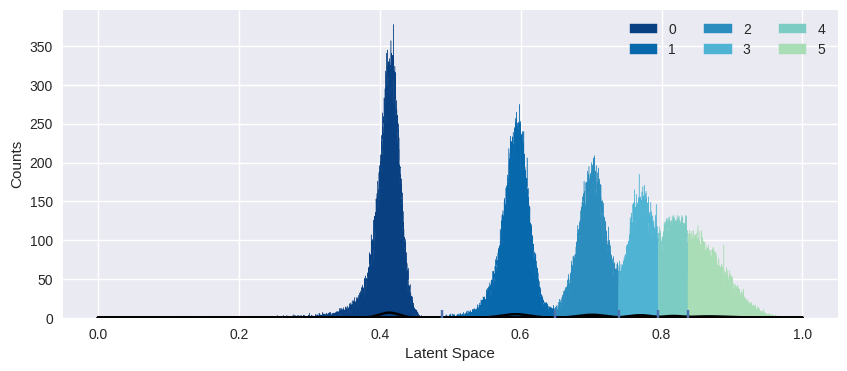

9.05


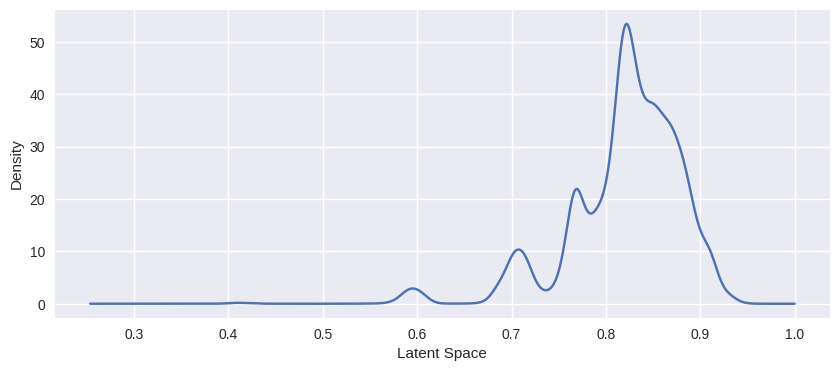

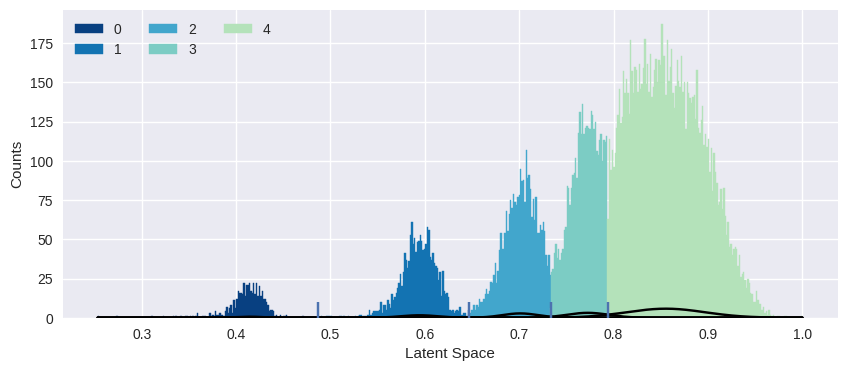

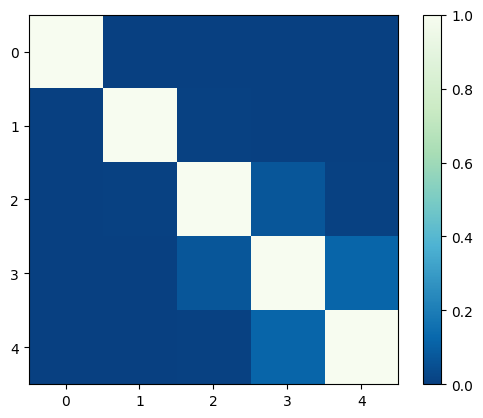

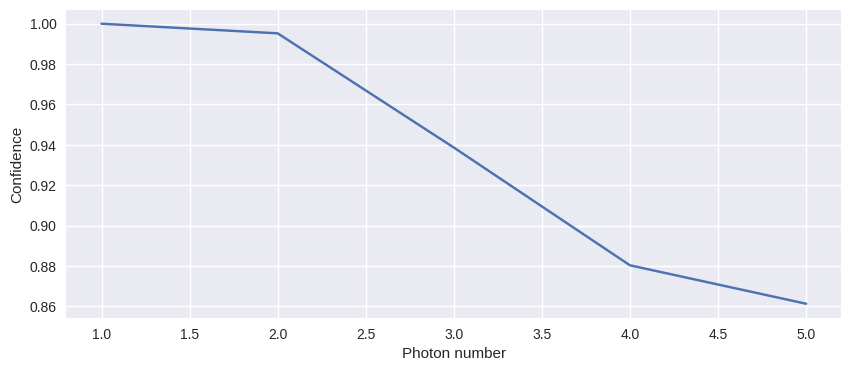

9.5


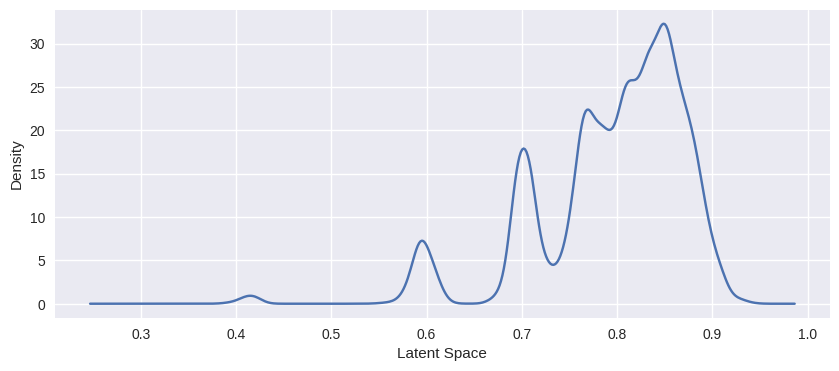

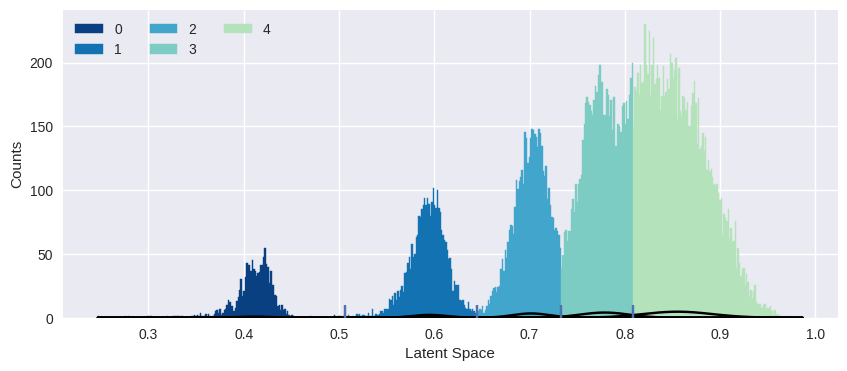

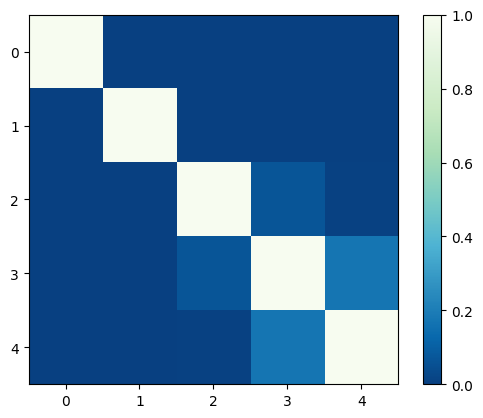

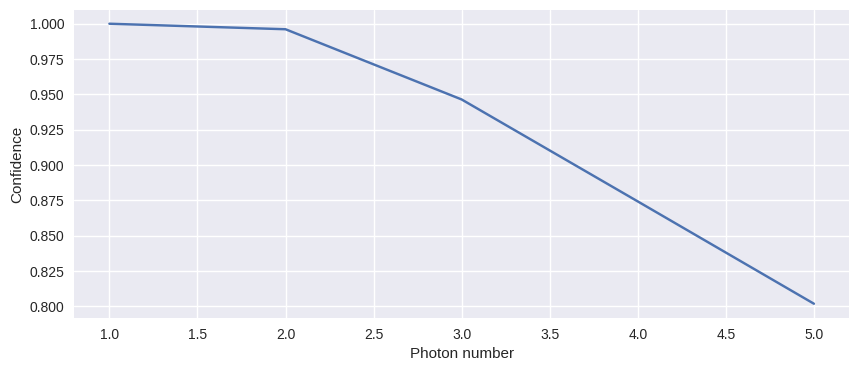

10.01


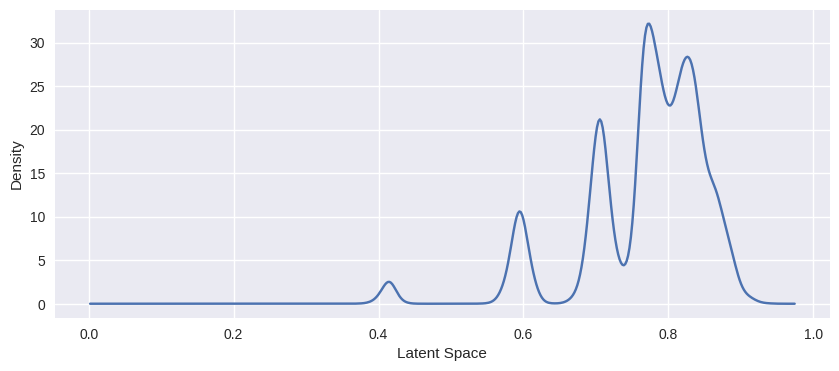

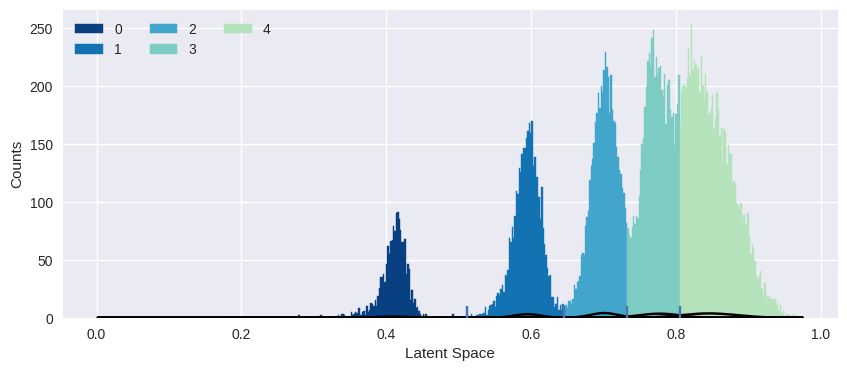

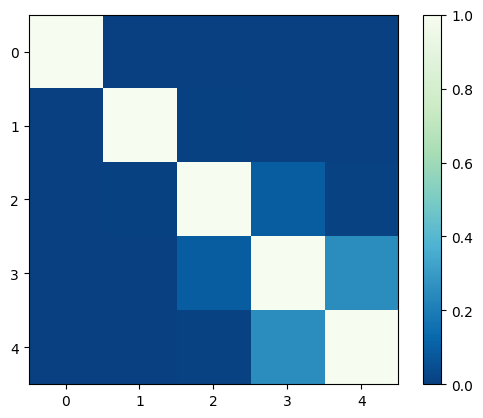

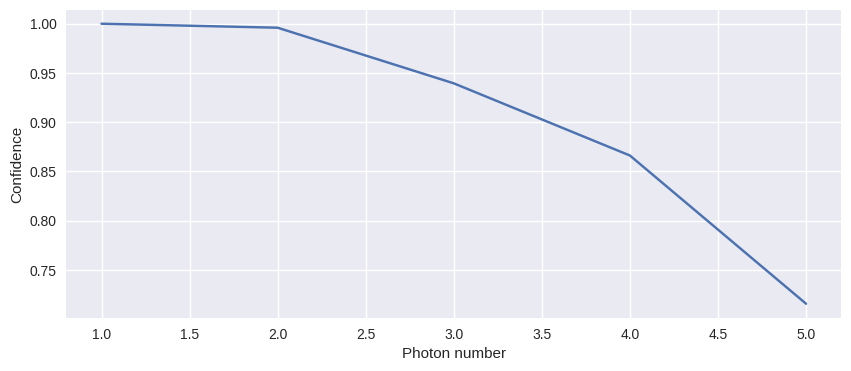

10.59


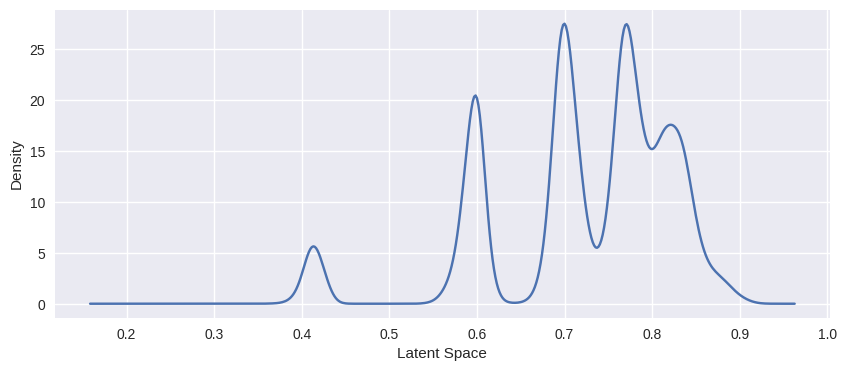

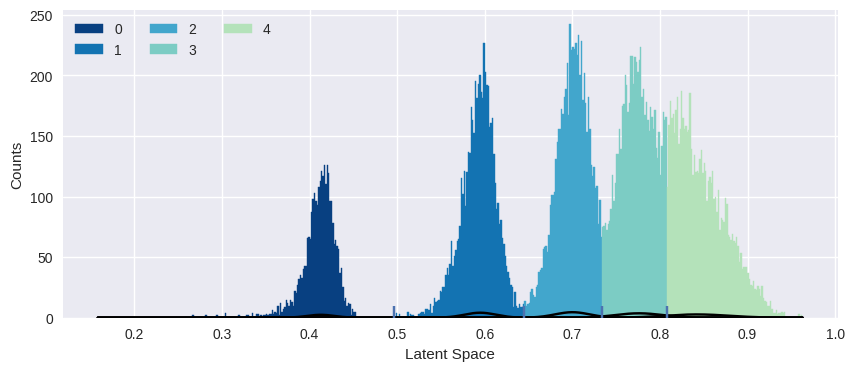

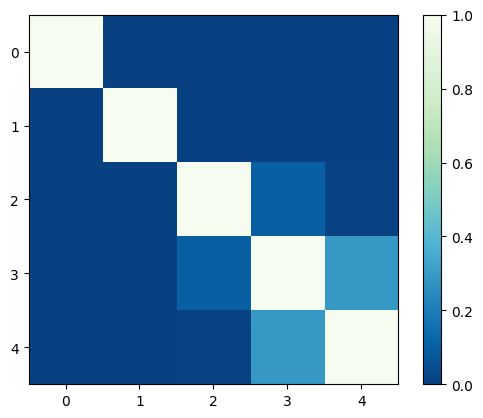

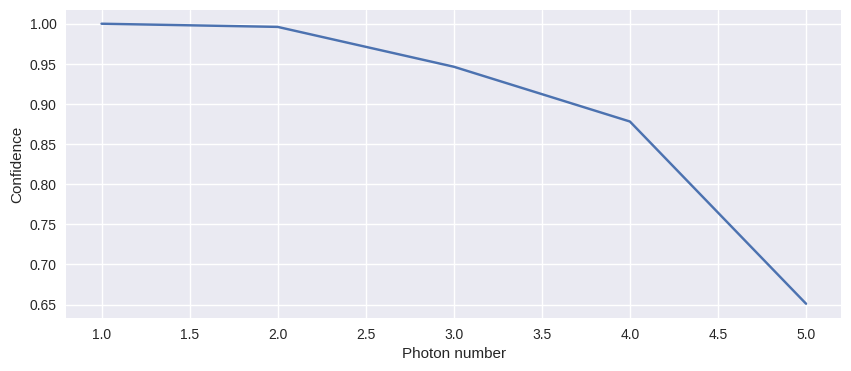

11.25


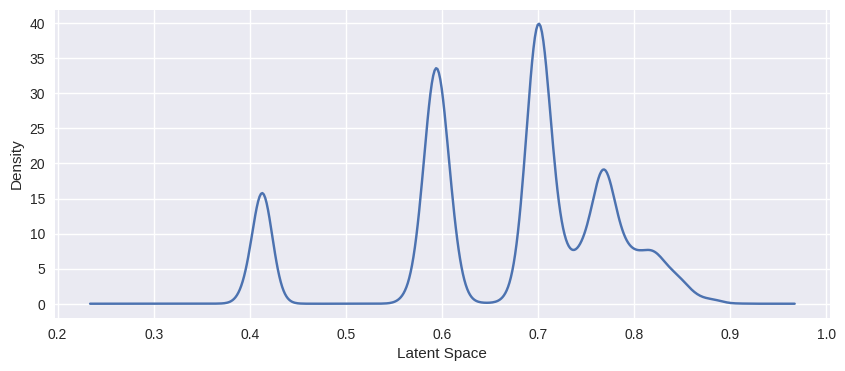

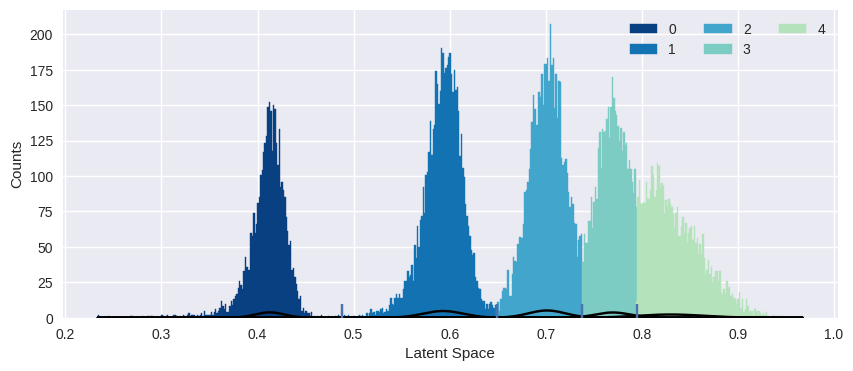

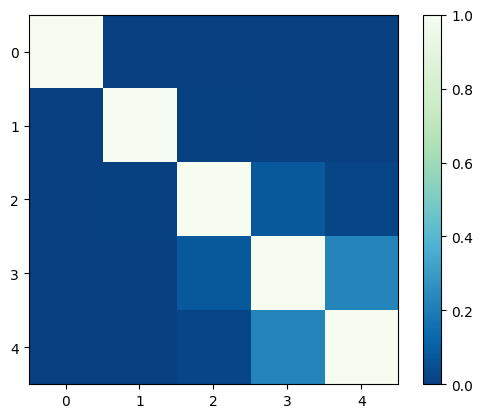

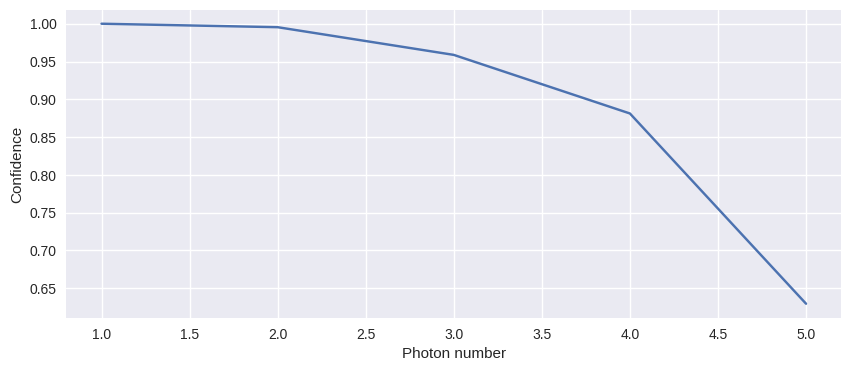

12.04


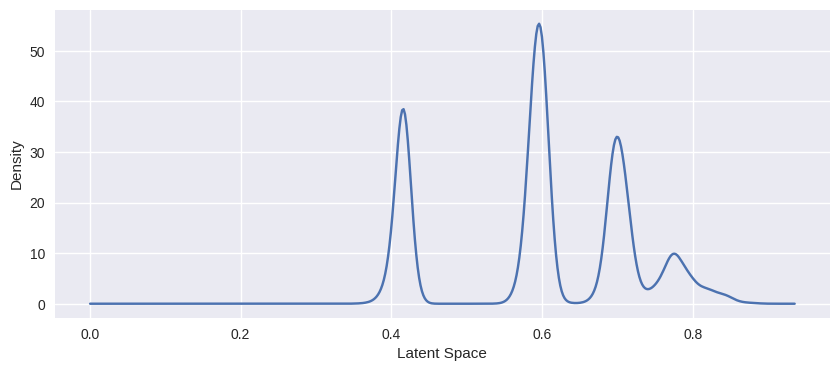

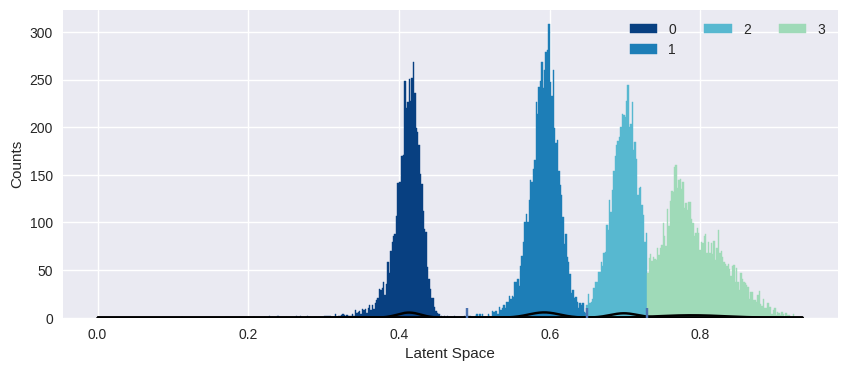

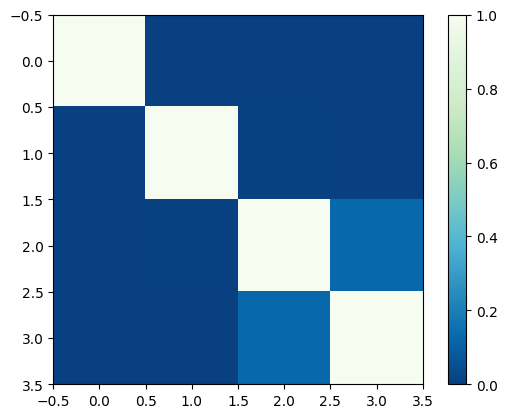

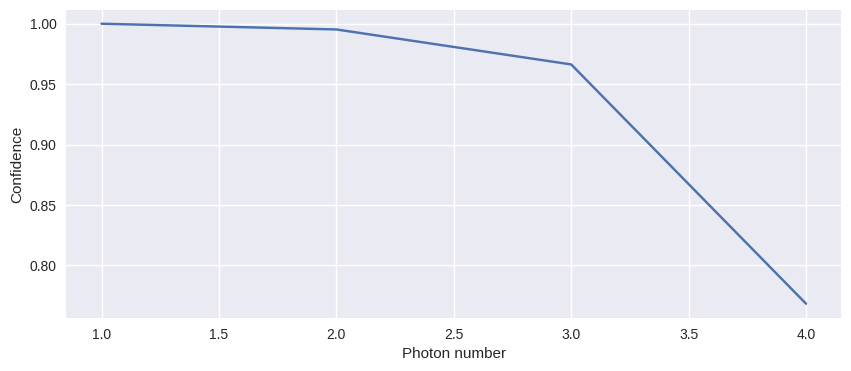

13.0


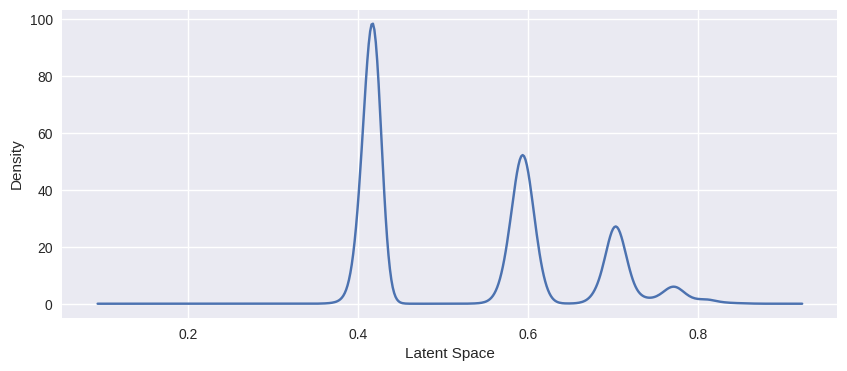

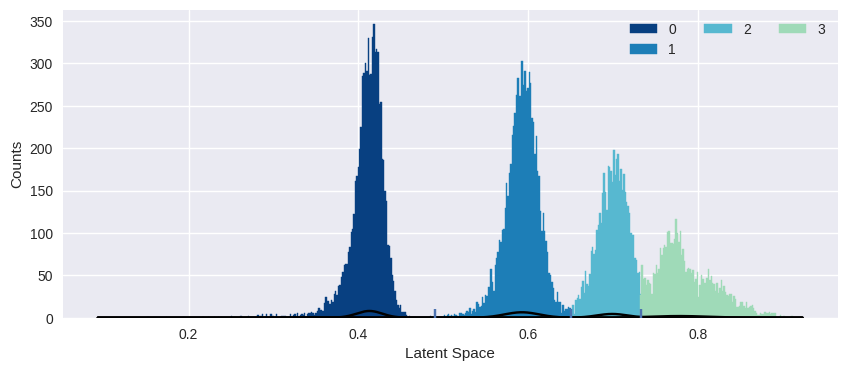

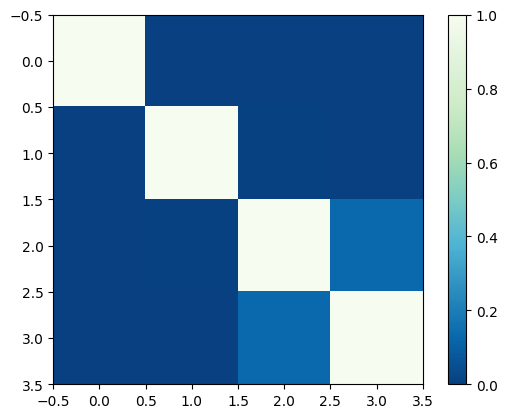

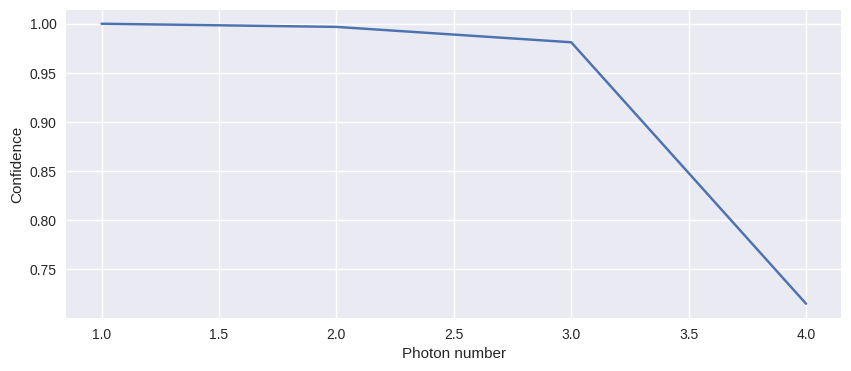

14.24


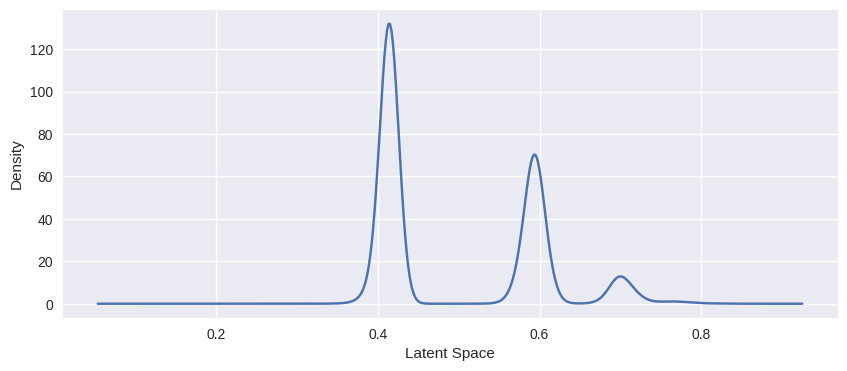

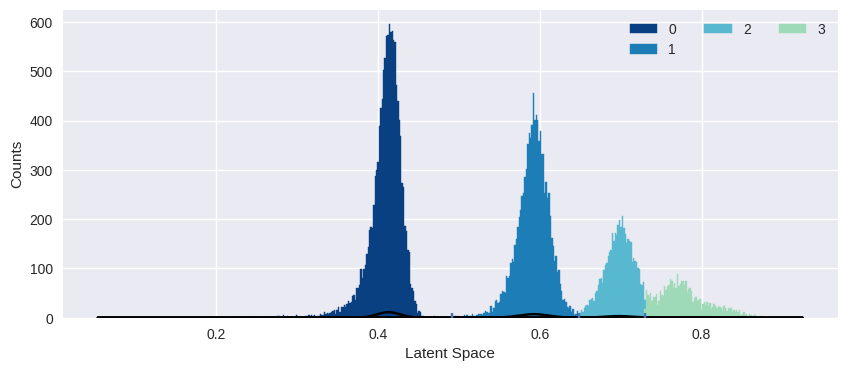

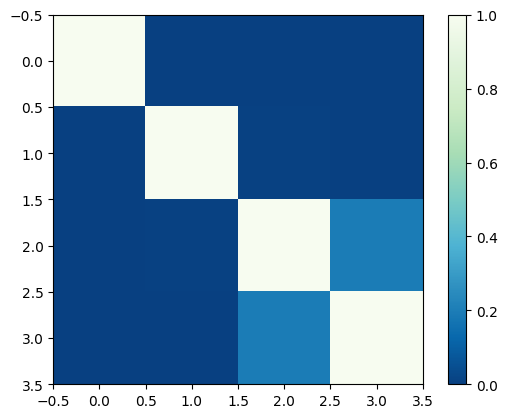

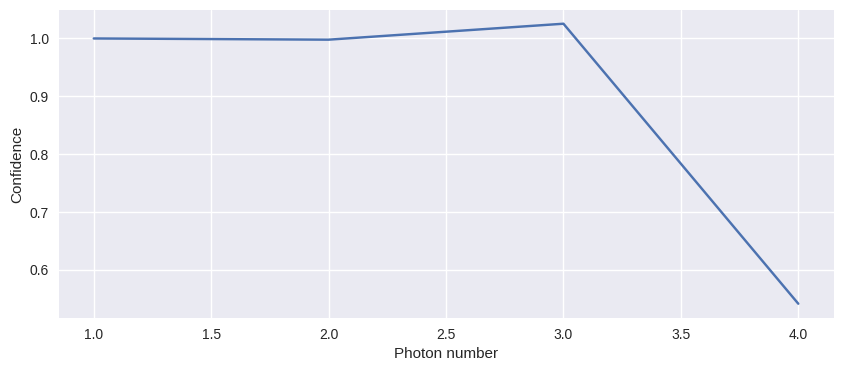

15.99


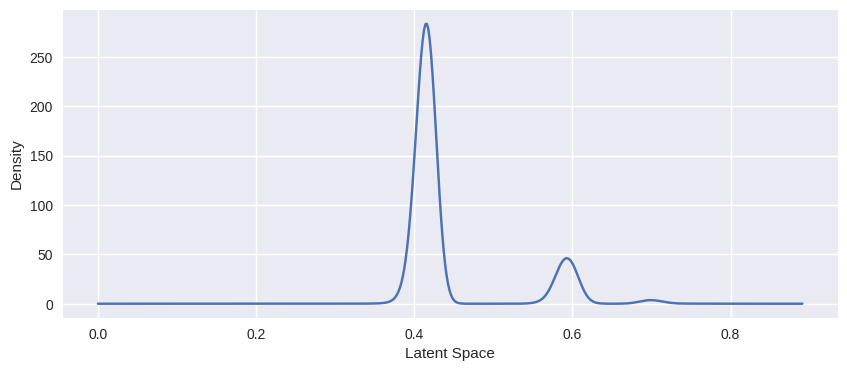

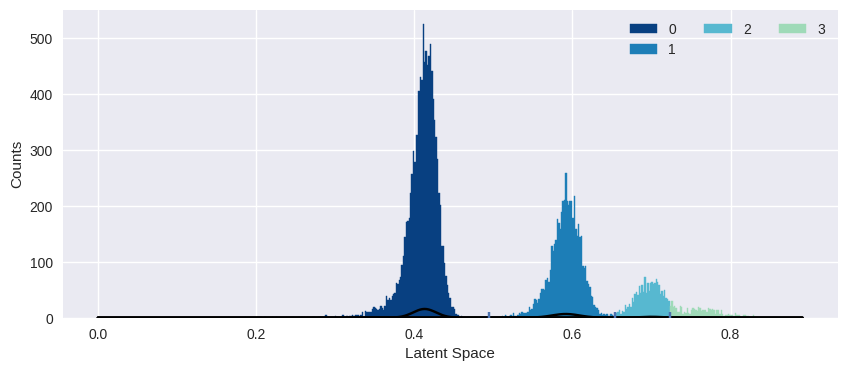

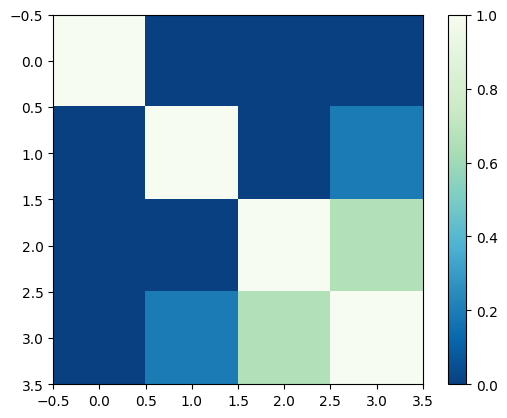

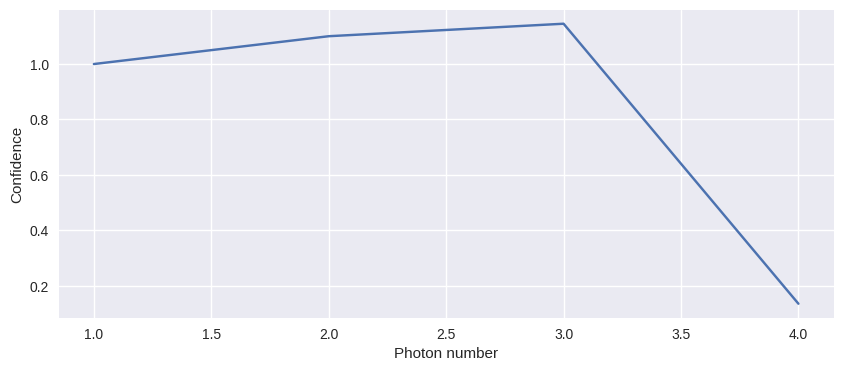

18.97


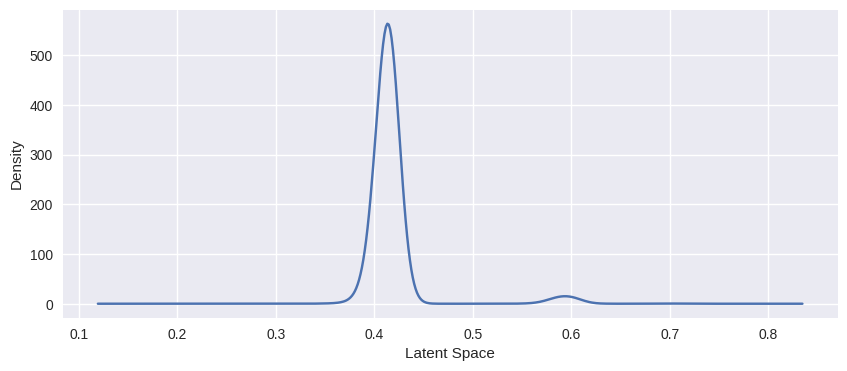

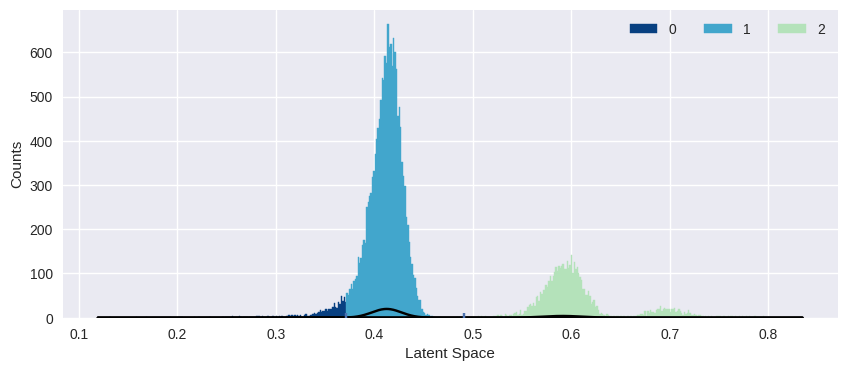

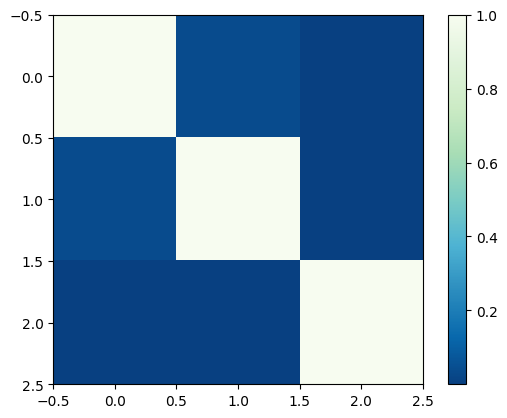

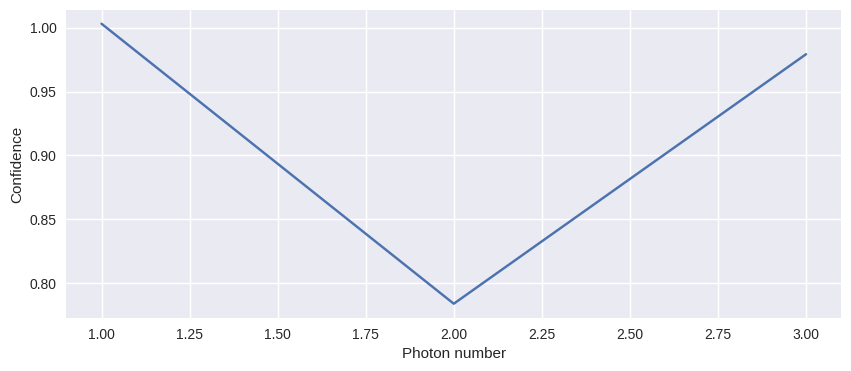

In [97]:
decibel = []
g2 = []
average = []

X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(X, f'AutoencoderLog/{path_model}', filter=False, flip=False)

conf = confidence(X_l_AUTO,
                bw = [0.005], 
                min_cluster_prob = 0.04,
                bins_plot = 5000,
                density_kernel='gaussian',
                flip = False, 
                skip = 10,
                size_plot = 10)

labels = conf.labels

bw_list = [0.008, 0.008, 0.01, 0.01, 0.01, 0.01, 0.01, 0.012, 0.012, 0.012]
min_prob_list = [0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.04, 0.04, 0.04]


for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key

    conf.fit(X_l_AUTO[condition],
            bw = [bw_list[index]], 
            min_cluster_prob = min_prob_list[index],
            bins_plot = 500,
            density_kernel='gaussian',
            flip = False, 
            skip = 10,
            size_plot = 10)
    
    labels_ = labels[condition]

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))